# Explanatory Data Analysis and Visualization

1. Data Overview and Structure (e.g., numerical, categorical...)
2. Quality Assessment (e.g., missing value, duplicate data, data type validation, ...)
3. Univariate Analysis (e.g., basic statistics, distribution checks, outlier detection, ...)
4. Bivariate/Multivariate Analysis (e.g., correlation, scatter plots, categorical analysis)
5. Feature Engineering Exploration (e.g., skewness correction (transformation), categorical cardinality (encoding), class imbalance)


In [1]:
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='joblib')
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Arial']

In [2]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

## 1. Data Overview and Structure

In [3]:
print('--- Data Types and Info ---')
df.info()

print('\n--- Descriptive Statistics ---')
display(df.describe())

--- Data Types and Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [4]:
# Identify numerical and categorical columns
numerical_cols = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 
    'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 
    'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
    'EmployeeCount', 'EmployeeNumber', 'StandardHours'
]

categorical_cols = [
    'BusinessTravel', 'Department', 'Education', 'EducationField', 
    'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel', 
    'JobRole', 'JobSatisfaction', 'MaritalStatus', 'OverTime', 
    'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 
    'WorkLifeBalance', 'Over18'
]

all_processed_cols = numerical_cols + categorical_cols + ['Attrition'] 
missing = [c for c in df.columns if c not in all_processed_cols]
if missing:
    print(f"Missing Col: {missing}")

print(f'Len(Numerical Columns): {len(numerical_cols)}')
print(f'Len(Categorical Columns): {len(categorical_cols)}')

Len(Numerical Columns): 17
Len(Categorical Columns): 17


## Quality Assessment

In [5]:
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")

Missing Values: 0
Duplicate Rows: 0


In [6]:
# Categorical Consistency Check
print("Current categorical columns:")
for col in categorical_cols:
    unique_values = df[col].unique()
    print(f"Unique values in column '{col}': {unique_values}")

Current categorical columns:
Unique values in column 'BusinessTravel': ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
Unique values in column 'Department': ['Sales' 'Research & Development' 'Human Resources']
Unique values in column 'Education': [2 1 4 3 5]
Unique values in column 'EducationField': ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
Unique values in column 'EnvironmentSatisfaction': [2 3 4 1]
Unique values in column 'Gender': ['Female' 'Male']
Unique values in column 'JobInvolvement': [3 2 4 1]
Unique values in column 'JobLevel': [2 1 3 4 5]
Unique values in column 'JobRole': ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
Unique values in column 'JobSatisfaction': [4 2 3 1]
Unique values in column 'MaritalStatus': ['Single' 'Married' 'Divorced']
Unique values in column 'OverTime': ['Yes' 'N

In [7]:
# Check constant columns (columns with only one unique value that does not help with analysis)
constant_columns = [col for col in df.columns if df[col].nunique() == 1]
print(f"Dataframe shape before removing constant columns: {df.shape}")
print(f"Constant columns: {constant_columns}")

# Remove constant columns
df.drop(columns=constant_columns, inplace=True)
print(f"Dataframe shape after removing constant columns: {df.shape}")

Dataframe shape before removing constant columns: (1470, 35)
Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']
Dataframe shape after removing constant columns: (1470, 32)


In [8]:
# Check unique identifier
if df['EmployeeNumber'].is_unique:
    print("EmployeeNumber is a unique identifier.")
    df.set_index('EmployeeNumber', inplace=True)

print(f"Dataframe shape after removing constant columns: {df.shape}")

EmployeeNumber is a unique identifier.
Dataframe shape after removing constant columns: (1470, 31)


## Univariate Analysis

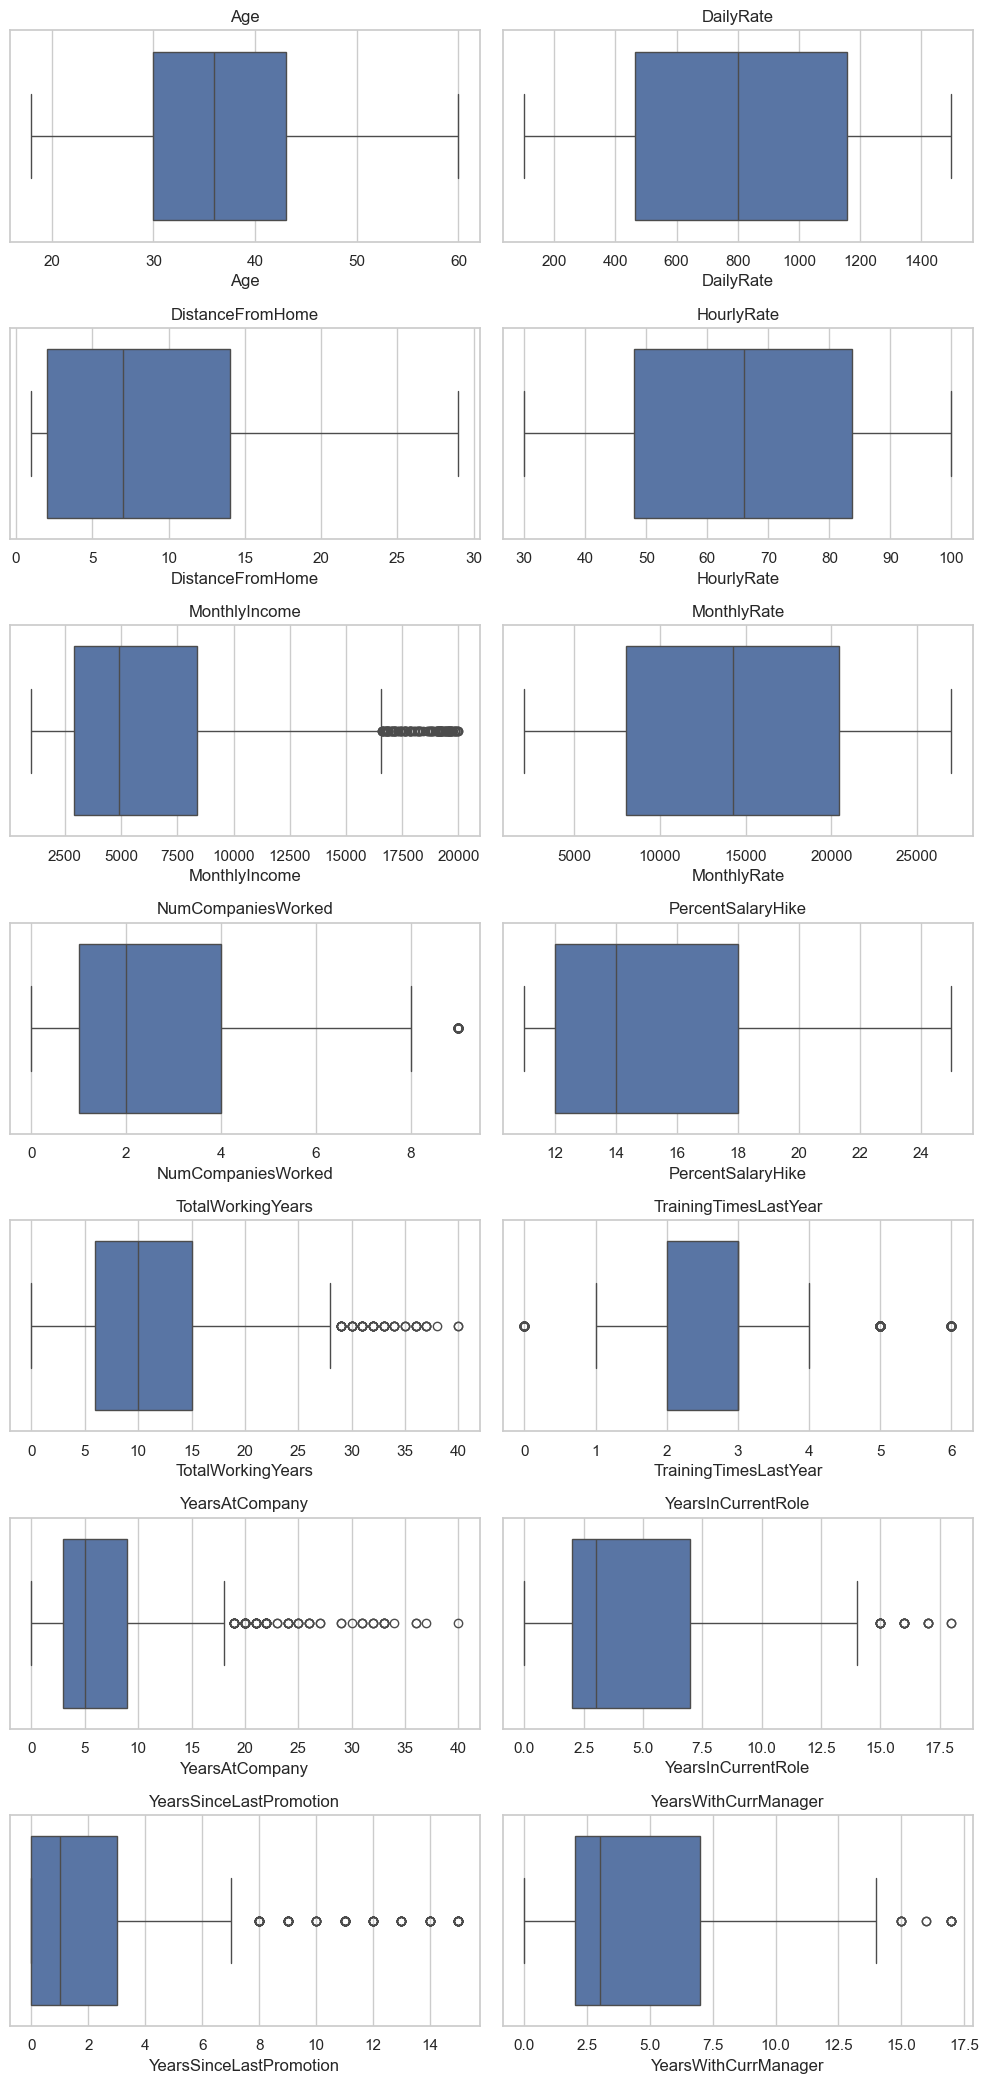

In [9]:
# Filter only necessary numerical_cols
numerical_cols = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 
    'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 
    'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

n = len(numerical_cols)
cols = 2  
rows = math.ceil(n / cols)

plt.figure(figsize=(5 * cols, 3 * rows))
for i, col in enumerate(numerical_cols):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'{col}')

plt.tight_layout()
plt.show()


In [10]:
# Winsorization function to cap outliers
def winsorize_series(series, lower_percentile=0.01, upper_percentile=0.99):
    lower_bound = series.quantile(lower_percentile)
    upper_bound = series.quantile(upper_percentile)
    return series.clip(lower=lower_bound, upper=upper_bound)

winsorize_series(df['YearsInCurrentRole'], lower_percentile=0.01, upper_percentile=0.99)
winsorize_series(df['YearsWithCurrManager'], lower_percentile=0.01, upper_percentile=0.99)
winsorize_series(df['NumCompaniesWorked'], lower_percentile=0.01, upper_percentile=0.99)

# Log transformation: MonthlyIncome, Total Working Years, YearsAtCompany, YearsSinceLastPromotion
df['MonthlyIncome'] = np.log1p(df['MonthlyIncome'])
df['TotalWorkingYears'] = np.log1p(df['TotalWorkingYears'])
df['YearsAtCompany'] = np.log1p(df['YearsAtCompany'])
df['YearsSinceLastPromotion'] = np.log1p(df['YearsSinceLastPromotion'])

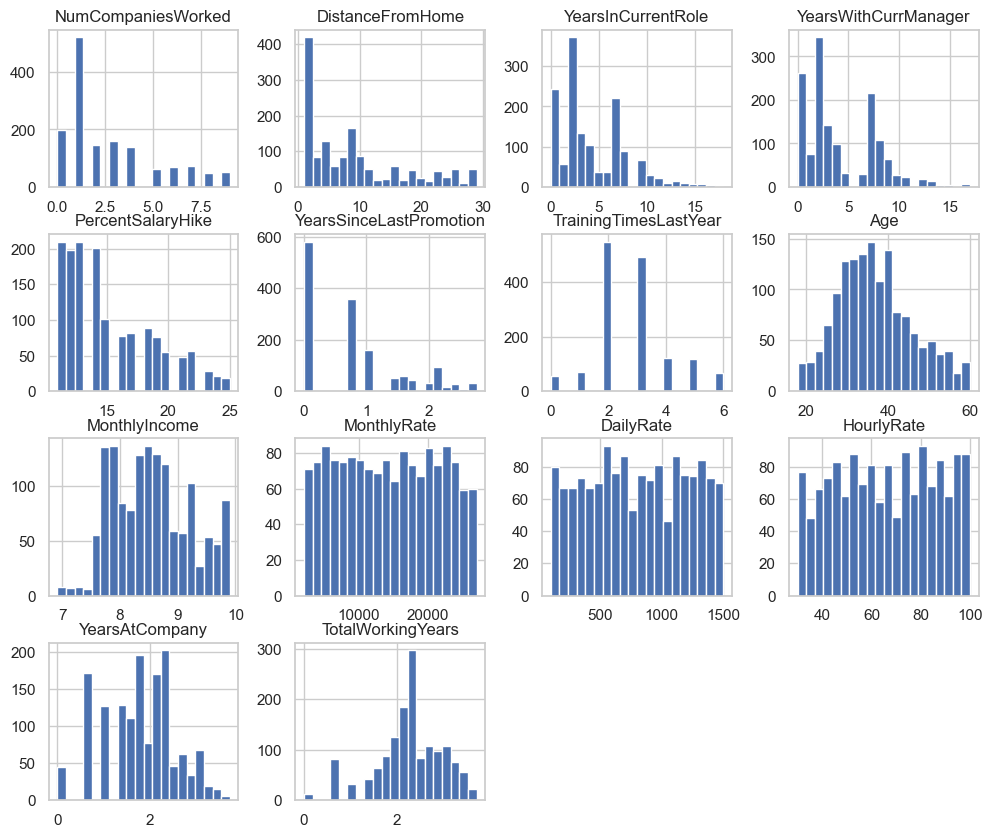

In [11]:
skew_summary = df[numerical_cols].skew().sort_values(ascending=False)
df[skew_summary.index].hist(bins=20, figsize=(12, 10))
plt.show()

In [12]:
# Identify skewed features (threshold > 0.75 or < -0.75)
skewness = df[numerical_cols].skew().sort_values(ascending=False)
skewness = skewness[abs(skewness) > 0.75]
print(skewness)

NumCompaniesWorked      1.026471
DistanceFromHome        0.958118
YearsInCurrentRole      0.917363
YearsWithCurrManager    0.833451
PercentSalaryHike       0.821128
dtype: float64


Skewness after processing:
DistanceFromHome       -0.007468
NumCompaniesWorked      0.014814
YearsInCurrentRole     -0.060849
YearsWithCurrManager   -0.067564
PercentSalaryHike       0.116250
dtype: float64


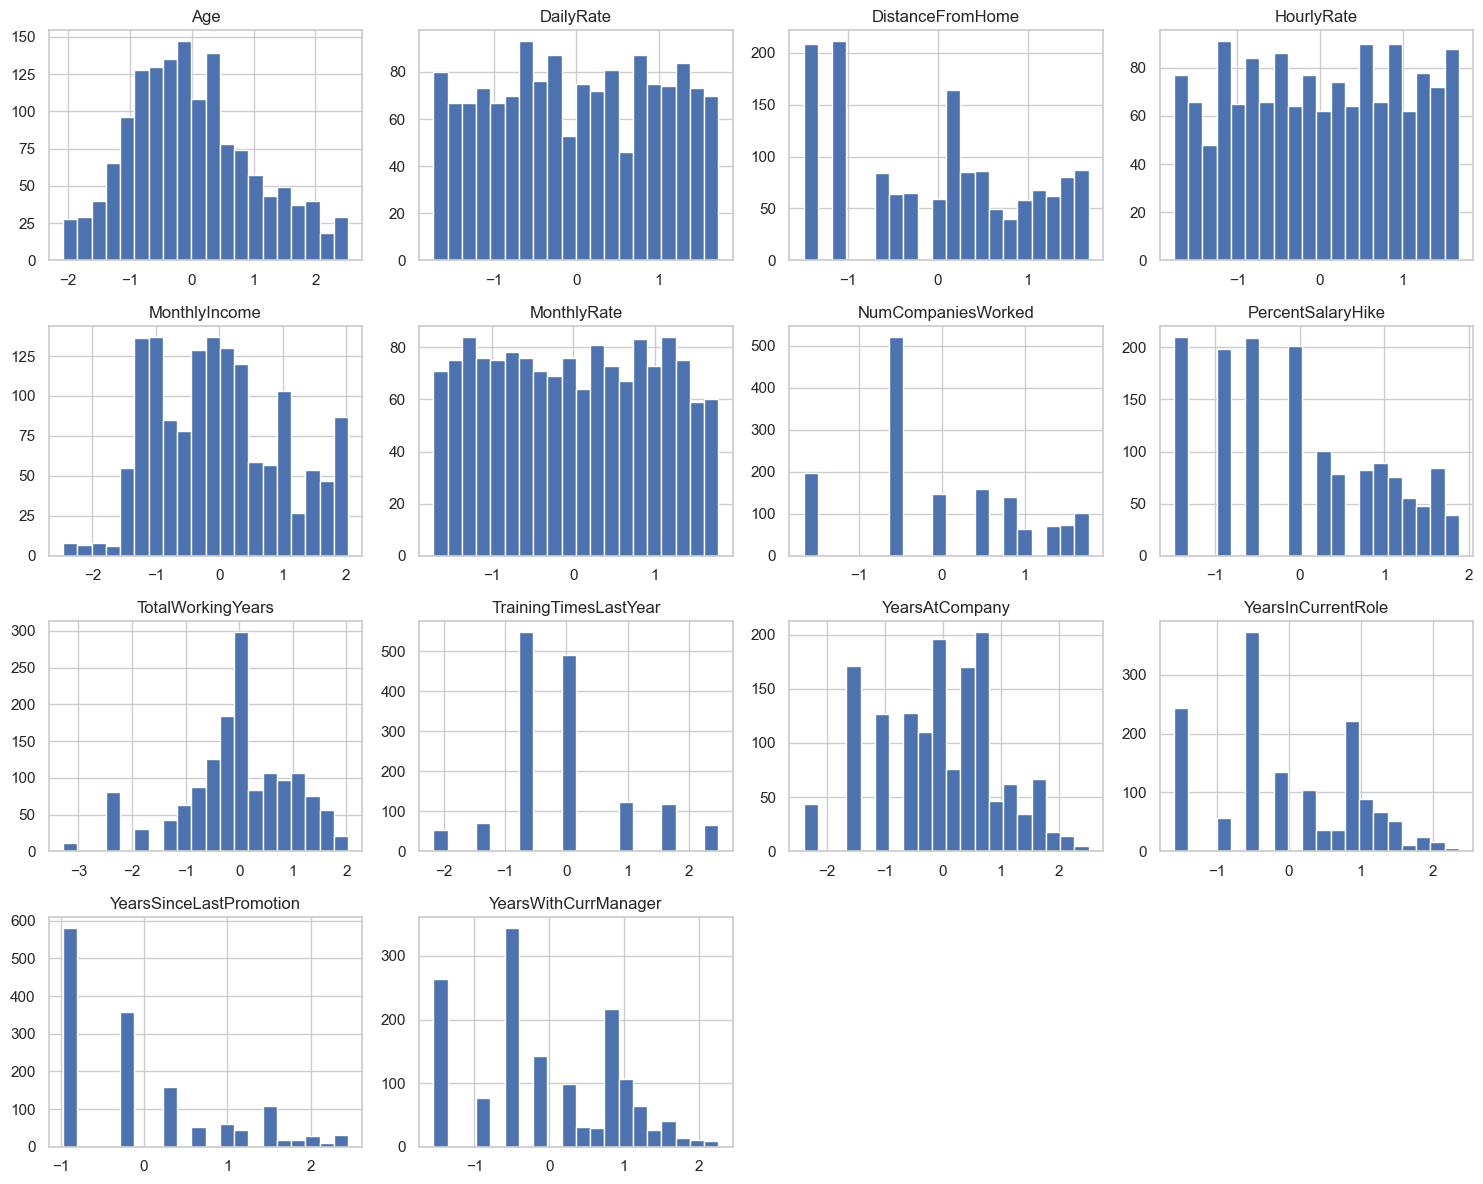

In [13]:
## Deal with skewness 
skewed_cols = ['DistanceFromHome', 'NumCompaniesWorked', 'YearsInCurrentRole', 'YearsWithCurrManager','PercentSalaryHike']


numerical_features = [col for col in numerical_cols if col in df.columns]

pt = PowerTransformer(method='yeo-johnson')
df[skewed_cols] = pt.fit_transform(df[skewed_cols])

scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])


print("Skewness after processing:")
print(df[skewed_cols].skew())

df[numerical_features].hist(bins=20, figsize=(15, 12))
plt.tight_layout()
plt.show()


## Bivariate/Multivariate Analysis

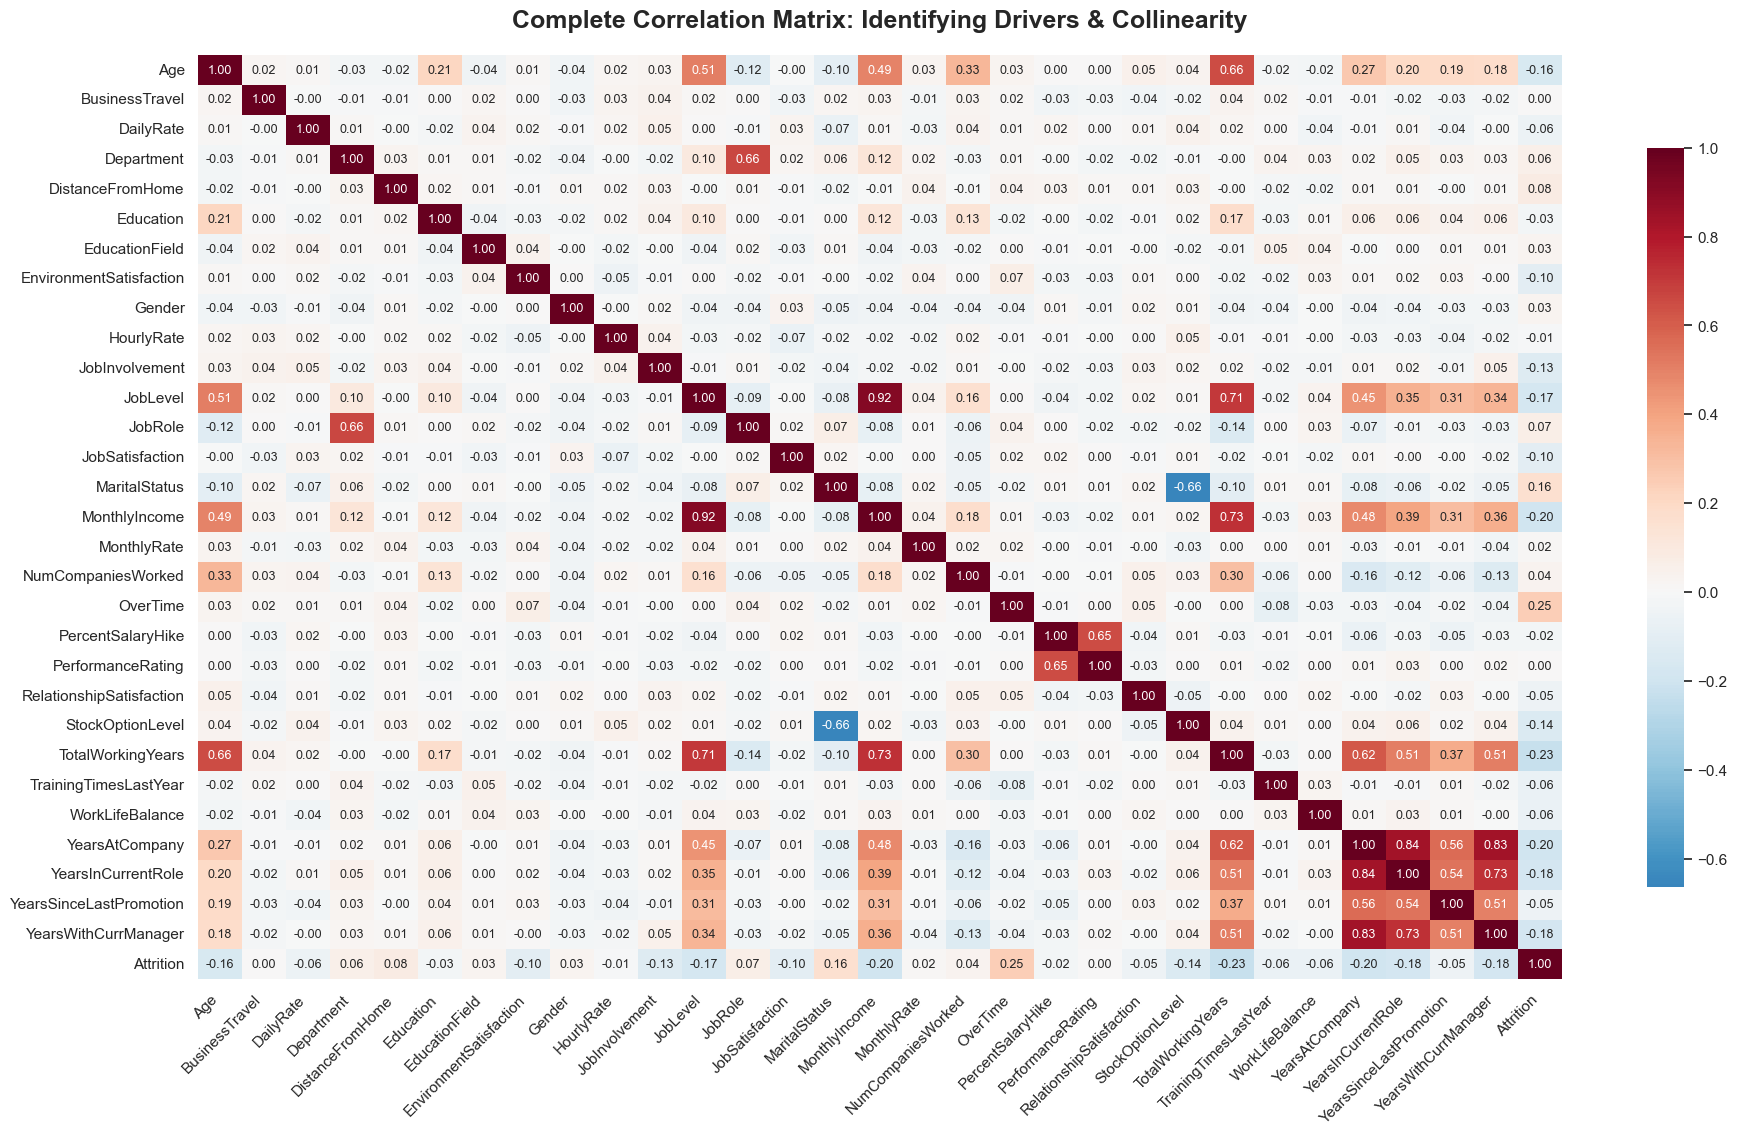

In [14]:
## Correlation Analysis
corr_df = df.copy()

corr_df['Attrition'] = corr_df['Attrition'].map({'Yes': 1, 'No': 0})
corr_df['OverTime'] = corr_df['OverTime'].map({'Yes': 1, 'No': 0})
corr_df['Gender'] = corr_df['Gender'].map({'Male': 1, 'Female': 0})


categorical_cols = [
    'BusinessTravel', 'Department', 'EducationField', 'MaritalStatus', 'JobRole'
]

for col in categorical_cols:
    if col in corr_df.columns:
        corr_df[col] = corr_df[col].astype('category').cat.codes


cols_to_drop = ['EmployeeCount', 'StandardHours', 'EmployeeNumber', 'Over18']  
final_df = corr_df.select_dtypes(include=[np.number]).drop(columns=cols_to_drop, errors='ignore')

all_cols = [c for c in final_df.columns if c != 'Attrition'] + ['Attrition']
final_corr_matrix = final_df[all_cols].corr()


plt.figure(figsize=(22, 12))

# Create mask to hide upper triangle 
# mask = np.triu(np.ones_like(final_corr_matrix, dtype=bool))

sns.heatmap(
    final_corr_matrix, 
    # mask=mask,
    annot=True,          
    fmt='.2f',           
    cmap='RdBu_r',       
    center=0,            
    annot_kws={"size": 9},
    cbar_kws={"shrink": .8}
)

plt.title('Complete Correlation Matrix: Identifying Drivers & Collinearity', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

In [15]:
# Remove JobLevel (highly correlated with MonthlyIncome: corr ~ 0.95)
final_df.drop(columns=['JobLevel'], inplace=True, errors='ignore') 
final_df.shape

(1470, 30)

## Feature Engineering

In [16]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
EmployeeNumber,,,,,,,,,,,,,,,,,,,,,
1,0.446350,Yes,Travel_Rarely,0.742527,Sales,-1.494085,2,Life Sciences,2,Female,...,3,1,0,-0.138921,-2.171982,1,0.177344,0.205562,-0.973342,0.490147
2,1.322365,No,Travel_Frequently,-1.297775,Research & Development,0.243416,1,Life Sciences,3,Male,...,4,4,1,0.148411,0.155707,3,0.774724,0.883888,-0.117271,0.909635
4,0.008343,Yes,Travel_Rarely,1.414363,Research & Development,-1.031215,2,Other,4,Male,...,3,2,0,-0.307569,0.155707,3,-2.394527,-1.596434,-0.973342,-1.550156
5,-0.429664,No,Travel_Frequently,1.461466,Research & Development,-0.700347,4,Life Sciences,4,Female,...,3,3,0,-0.138921,0.155707,3,0.509502,0.883888,0.738799,-1.550156
7,-1.086676,No,Travel_Rarely,-0.524295,Research & Development,-1.031215,1,Medical,1,Male,...,3,4,1,-0.498767,0.155707,3,-0.942513,-0.446645,0.383498,-0.406881


In [17]:
# Target variable encoding
df['Attrition_Num'] = df['Attrition'].map({'Yes': 1, 'No': 0})
X = df.drop(['Attrition', 'Attrition_Num'], axis=1).copy()
y = df['Attrition_Num']

# Binary Encoding for 'OverTime' and 'Gender'
X['OverTime'] = X['OverTime'].map({'Yes': 1, 'No': 0})
X['Gender'] = X['Gender'].map({'Male': 1, 'Female': 0})

if 'JobLevel' in X.columns:
    X = X.drop(columns='JobLevel')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Target Encoding

for col in ['JobRole', 'EducationField']:
    target_map = X_train.join(y_train).groupby(col)['Attrition_Num'].mean()
    X_train[col + '_Encoded'] = X_train[col].map(target_map)
    X_test[col + '_Encoded'] = X_test[col].map(target_map)
    X_train = X_train.drop(columns=col)
    X_test = X_test.drop(columns=col)

# One-hot encoding for remaining categorical columns 
exclude_cols = ['OverTime', 'Gender', 'JobRole_Encoded', 'EducationField_Encoded']
categorical_cols_to_encode = [col for col in X_train.select_dtypes(include='object').columns if col not in exclude_cols]
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols_to_encode, drop_first=True, dtype=int)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols_to_encode, drop_first=True, dtype=int)

X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

In [18]:
print(X_train_encoded.shape, X_test_encoded.shape, y_train.shape, y_test.shape)

(1176, 32) (294, 32) (1176,) (294,)


## Check Class Imbalance

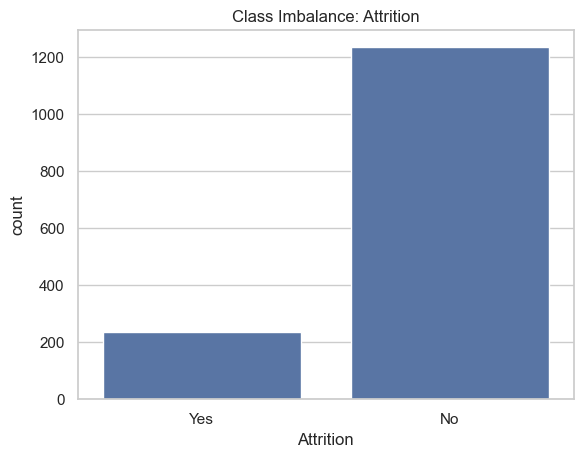

In [19]:
# Class Imbalance Check
    
sns.countplot(x='Attrition', data=df)
plt.title('Class Imbalance: Attrition')
plt.show()

----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
# Blackbox Models

## Why this notebook differs from the EDA notebook
- Preprocessing is wrapped inside sklearn pipelines so train/test leakage is avoided
- Class imbalance is handled with imbalance-aware metrics and class weights
- Model selection is based primarily on PR-AUC because attrition is the minority class


In [20]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)

RANDOM_STATE = 42

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13


## Load The Reduced-Column Dataset
- Train, Validation, Test splits


In [21]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
original_shape = df.shape


print(f"Original shape: {original_shape}")
print(f"Shape after reductions: {df.shape}")

print()
print("Target distribution:")
print(df["Attrition"].value_counts())

df.head()

Original shape: (1470, 35)
Shape after reductions: (1470, 35)

Target distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2



```
Original Data (1,470 samples)
│
├─ Training: 60% (882 samples) → Model training via 5-fold CV
├─ Validation: 20% (294 samples) → Threshold tuning (F2 optimization)
└─ Test: 20% (294 samples) → Final evaluation (truly held-out)
```

In [22]:
X = df.drop(columns=["Attrition"]).copy()
y = df["Attrition"].map({"Yes": 1, "No": 0})

# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Second split: split the 80% into 75% model training, 25% validation
# This gives us: 60% model training, 20% validation, 20% test
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()

categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print()
print("Data Split Summary (Train/Validation/Test):")
print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print("="*50)
print()
print(f"Model training shape: {X_train.shape}")
print(f"Full data positive rate: {round(y.mean(), 4)} (Attrition%)")
print()
print(f"Validation shape: {X_val.shape}")
print(f"Validation positive rate: {round(y_val.mean(), 4)} (Attrition%)")
print()
print(f"Test shape: {X_test.shape}")
print(f"Test positive rate: {round(y_test.mean(), 4)} (Attrition%)")
print()
print(f"Train positive rate: {round(y_train.mean(), 4)} (Attrition%)")
print("Class Distribution by Set:")

Categorical features (8): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Data Split Summary (Train/Validation/Test):
Numeric features (26): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Model training shape: (882, 34)
Full data positive rate: 0.1612 (Attrition%)

Validation shape: (294, 34)
Validation positive rate: 0.1599 (Attrition%)

Test shape: (294, 34)
Test positive rate: 0.1599 (Attrition%)

Train positive rate: 0.1621 (Attrition%)
Class Distribution by Set:


## Modelling Strategy

A few choices here are intentional:

- `PR-AUC` is the main selection metric because attrition is the minority class.
- `ROC-AUC`, `F1`, `Recall`, `Precision`, and `Balanced Accuracy` are tracked as supporting metrics.
- Preprocessing is done inside each pipeline so cross-validation stays leakage-safe.
- For imbalance handling, the notebook leans on class weights

In [23]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False,
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

preprocessor_unscaled = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False,
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

candidate_models = {
    "Logistic Regression": {
        "pipeline": Pipeline(
            steps=[
                ("prep", preprocessor_scaled),
                (
                    "model",
                    LogisticRegression(
                        max_iter=2000,
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "is_blackbox": False,
    },
    "KNN": {
        "pipeline": Pipeline(
            steps=[
                ("prep", preprocessor_scaled),
                ("model", KNeighborsClassifier(n_neighbors=11)),
            ]
        ),
        "is_blackbox": True,
    },
    "SVM (RBF)": {
        "pipeline": Pipeline(
            steps=[
                ("prep", preprocessor_scaled),
                (
                    "model",
                    SVC(
                        kernel="rbf",
                        C=1.0,
                        gamma="scale",
                        class_weight="balanced",
                        probability=True,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "is_blackbox": True,
    },
    "Random Forest": {
        "pipeline": Pipeline(
            steps=[
                ("prep", preprocessor_unscaled),
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=400,
                        min_samples_leaf=2,
                        class_weight="balanced_subsample",
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "is_blackbox": True,
    },
    "Extra Trees": {
        "pipeline": Pipeline(
            steps=[
                ("prep", preprocessor_unscaled),
                (
                    "model",
                    ExtraTreesClassifier(
                        n_estimators=500,
                        min_samples_leaf=2,
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "is_blackbox": True,
    },
    "HistGradientBoosting": {
        "pipeline": Pipeline(
            steps=[
                ("prep", preprocessor_unscaled),
                (
                    "model",
                    HistGradientBoostingClassifier(
                        learning_rate=0.05,
                        max_depth=6,
                        max_iter=300,
                        min_samples_leaf=20,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "is_blackbox": True,
    },
}

scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
    "balanced_accuracy": "balanced_accuracy",
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


In [24]:
cv_rows = []

for name, meta in candidate_models.items():
    scores = cross_validate(
        meta["pipeline"],
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
    )

    row = {
        "model": name,
        "is_blackbox": meta["is_blackbox"],
    }
    for metric in scoring:
        row[f"cv_mean_{metric}"] = scores[f"test_{metric}"].mean()
        row[f"cv_std_{metric}"] = scores[f"test_{metric}"].std()
    cv_rows.append(row)

cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values(
        ["cv_mean_pr_auc", "cv_mean_recall", "cv_mean_roc_auc"],
        ascending=False,
    )
    .reset_index(drop=True)
)

cv_results.style.format(
    {
        col: "{:.3f}"
        for col in cv_results.columns
        if col.startswith("cv_mean_") or col.startswith("cv_std_")
    }
)


,model,is_blackbox,cv_mean_pr_auc,cv_std_pr_auc,cv_mean_roc_auc,cv_std_roc_auc,cv_mean_f1,cv_std_f1,cv_mean_recall,cv_std_recall,cv_mean_precision,cv_std_precision,cv_mean_balanced_accuracy,cv_std_balanced_accuracy
0,Logistic Regression,False,0.582,0.037,0.825,0.007,0.495,0.044,0.727,0.040,0.377,0.048,0.745,0.028
1,SVM (RBF),True,0.555,0.056,0.812,0.013,0.507,0.049,0.559,0.032,0.465,0.063,0.716,0.027
2,Random Forest,True,0.549,0.076,0.795,0.018,0.285,0.073,0.175,0.046,0.767,0.200,0.582,0.027
3,Extra Trees,True,0.521,0.064,0.782,0.023,0.391,0.056,0.280,0.040,0.655,0.119,0.625,0.024
4,HistGradientBoosting,True,0.500,0.045,0.781,0.030,0.361,0.099,0.258,0.088,0.633,0.090,0.615,0.044
5,KNN,True,0.325,0.047,0.690,0.026,0.053,0.049,0.028,0.026,0.600,0.490,0.513,0.014


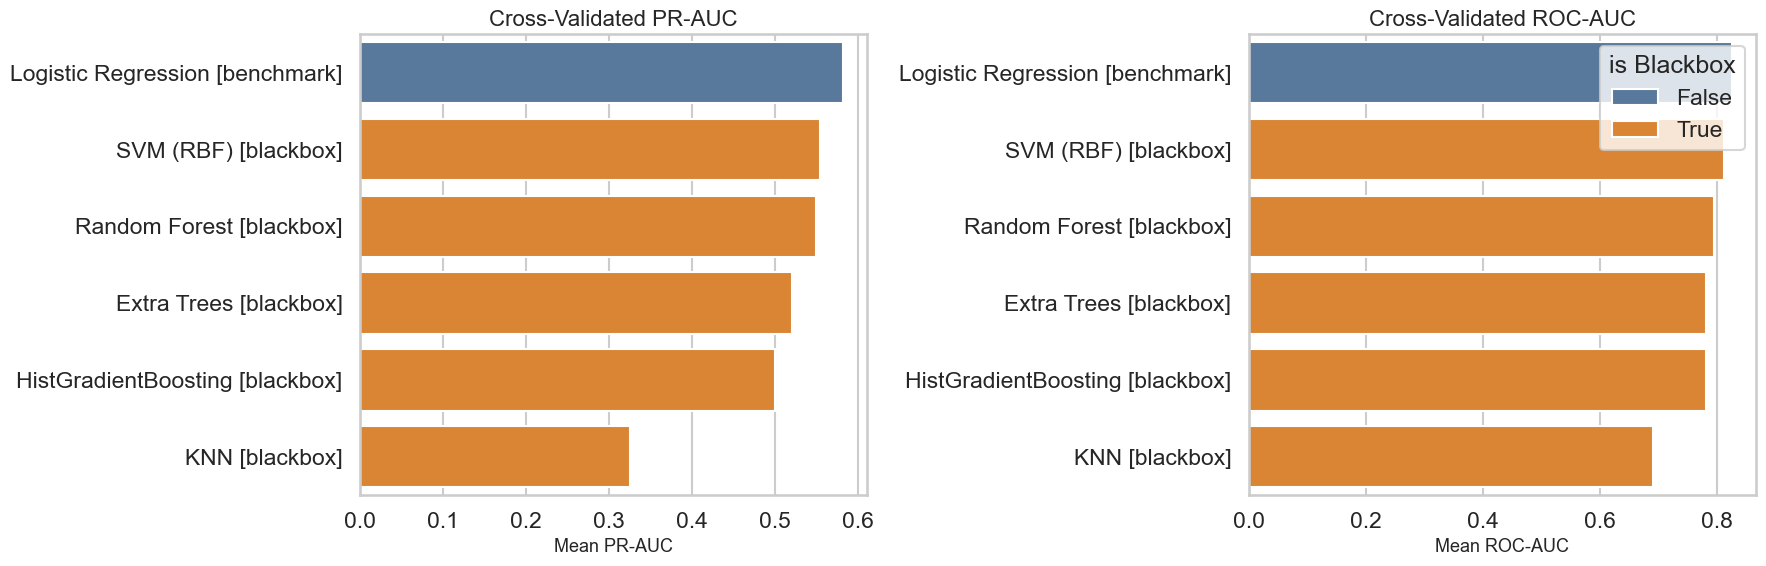

In [25]:
plot_df = cv_results.copy()
plot_df["model_label"] = np.where(
    plot_df["is_blackbox"],
    plot_df["model"] + " [blackbox]",
    plot_df["model"] + " [benchmark]",
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=plot_df,
    y="model_label",
    x="cv_mean_pr_auc",
    hue="is_blackbox",
    dodge=False,
    palette=["#4C78A8", "#F58518"],
    ax=axes[0],
)
axes[0].set_title("Cross-Validated PR-AUC")
axes[0].set_xlabel("Mean PR-AUC")
axes[0].set_ylabel("")
axes[0].legend_.remove()

sns.barplot(
    data=plot_df,
    y="model_label",
    x="cv_mean_roc_auc",
    hue="is_blackbox",
    dodge=False,
    palette=["#4C78A8", "#F58518"],
    ax=axes[1],
)
axes[1].set_title("Cross-Validated ROC-AUC")
axes[1].set_xlabel("Mean ROC-AUC")
axes[1].set_ylabel("")
axes[1].legend(title="is Blackbox")

plt.tight_layout()
plt.show()


In [26]:
best_cv_overall = cv_results.iloc[0]
best_cv_blackbox = (
    cv_results[cv_results["is_blackbox"]]
    .sort_values(["cv_mean_pr_auc", "cv_mean_recall", "cv_mean_roc_auc"], ascending=False)
    .iloc[0]
)

print("Best overall CV model:")
print(best_cv_overall[["model", "cv_mean_pr_auc", "cv_mean_roc_auc", "cv_mean_recall"]])
print()
print("Best blackbox CV model:")
print(best_cv_blackbox[["model", "cv_mean_pr_auc", "cv_mean_roc_auc", "cv_mean_recall"]])


Best overall CV model:
model              Logistic Regression
cv_mean_pr_auc                0.581688
cv_mean_roc_auc               0.825213
cv_mean_recall                 0.72734
Name: 0, dtype: object

Best blackbox CV model:
model              SVM (RBF)
cv_mean_pr_auc      0.554544
cv_mean_roc_auc     0.811698
cv_mean_recall      0.559113
Name: 1, dtype: object


## Hyperparameter Tuning via Cross-Validation
To keep the notebook efficient but still iterative, I tune:

- the top 2 models overall by cross-validated PR-AUC
- plus the top blackbox model if it is not already in that top 2

Hyperparameter search uses 5-fold stratified cross-validation on the training set and evaluate on the tuning on validation set

In [27]:
finalists = cv_results["model"].head(2).tolist()
best_blackbox_name = best_cv_blackbox["model"]
if best_blackbox_name not in finalists:
    finalists.append(best_blackbox_name)

finalists


['Logistic Regression', 'SVM (RBF)']

In [28]:
search_spaces = {
    "Logistic Regression": {
        "model__C": np.logspace(-2, 2, 10),
        "model__solver": ["lbfgs"],
        "model__class_weight": ["balanced"],
    },
    "KNN": {
        "model__n_neighbors": [5, 7, 9, 11, 15, 21],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2],
    },
    "SVM (RBF)": {
        "model__C": [0.5, 1, 2, 5, 10],
        "model__gamma": ["scale", 0.01, 0.03, 0.05, 0.1],
    },
    "Random Forest": {
        "model__n_estimators": [300, 500, 700],
        "model__max_depth": [None, 8, 12, 16],
        "model__min_samples_leaf": [1, 2, 4, 6],
        "model__min_samples_split": [2, 5, 10],
        "model__max_features": ["sqrt", "log2", None],
        "model__class_weight": ["balanced", "balanced_subsample"],
    },
    "Extra Trees": {
        "model__n_estimators": [300, 500, 700],
        "model__max_depth": [None, 8, 12, 16],
        "model__min_samples_leaf": [1, 2, 4, 6],
        "model__min_samples_split": [2, 5, 10],
        "model__max_features": ["sqrt", "log2", None],
        "model__class_weight": ["balanced", "balanced_subsample"],
    },
    "HistGradientBoosting": {
        "model__learning_rate": [0.03, 0.05, 0.08, 0.1],
        "model__max_depth": [None, 4, 6, 8],
        "model__max_leaf_nodes": [15, 31, 63],
        "model__min_samples_leaf": [10, 20, 30],
        "model__l2_regularization": [0.0, 0.1, 0.5, 1.0],
        "model__max_iter": [200, 300, 400],
    },
}

n_iter_lookup = {
    "Logistic Regression": 10,
    "KNN": 10,
    "SVM (RBF)": 10,
    "Random Forest": 12,
    "Extra Trees": 12,
    "HistGradientBoosting": 12,
}

tuned_searches = {}
tuned_rows = []

for name in finalists:
    search = RandomizedSearchCV(
        estimator=candidate_models[name]["pipeline"],
        param_distributions=search_spaces[name],
        n_iter=n_iter_lookup[name],
        scoring="average_precision",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=True,
    )
    # Step 1: Hyperparameter tuning via cross-validation on TRAINING set
    search.fit(X_train, y_train)
    tuned_searches[name] = search

    # Step 2: Evaluate on VALIDATION set to select best model
    val_proba = search.best_estimator_.predict_proba(X_val)[:, 1]
    val_pred = (val_proba >= 0.5).astype(int)

    tuned_rows.append(
        {
            "model": name,
            "is_blackbox": candidate_models[name]["is_blackbox"],
            "best_params": search.best_params_,
            "cv_best_pr_auc": search.best_score_,
            # Validation metrics only (for model selection)
            "val_pr_auc": average_precision_score(y_val, val_proba),
            "val_roc_auc": roc_auc_score(y_val, val_proba),
            "val_f1": f1_score(y_val, val_pred),
            "val_recall": recall_score(y_val, val_pred),
            "val_precision": precision_score(y_val, val_pred, zero_division=0),
            "val_balanced_accuracy": balanced_accuracy_score(y_val, val_pred),
        }
    )

tuned_results = (
    pd.DataFrame(tuned_rows)
    .sort_values(["val_pr_auc", "val_recall"], ascending=False)
    .reset_index(drop=True)
)

tuned_results


,model,is_blackbox,best_params,cv_best_pr_auc,val_pr_auc,val_roc_auc,val_f1,val_recall,val_precision,val_balanced_accuracy
0,SVM (RBF),True,"{'model__gamma': 0.01, 'model__C': 0.5}",0.601993,0.584116,0.802222,0.540541,0.425532,0.740741,0.698596
1,Logistic Regression,False,"{'model__solver': 'lbfgs', 'model__class_weigh...",0.606686,0.582321,0.803859,0.496241,0.702128,0.383721,0.743776


In [29]:
# Step 3: Final test evaluation (truly held-out)
best_overall_final = tuned_results.iloc[0]
best_overall_name = best_overall_final["model"]
best_overall_estimator = tuned_searches[best_overall_name].best_estimator_

best_blackbox_final = (
    tuned_results[tuned_results["is_blackbox"]]
    .sort_values(["val_pr_auc", "val_recall"], ascending=False)
    .iloc[0]
)
best_blackbox_name = best_blackbox_final["model"]
best_blackbox_estimator = tuned_searches[best_blackbox_name].best_estimator_

# NOW evaluate on test set (once, for final report)
overall_test_proba = best_overall_estimator.predict_proba(X_test)[:, 1]
overall_test_pred = (overall_test_proba >= 0.5).astype(int)

blackbox_test_proba = best_blackbox_estimator.predict_proba(X_test)[:, 1]
blackbox_test_pred = (blackbox_test_proba >= 0.5).astype(int)

print("="*70)
print("FINAL TEST SET EVALUATION (Threshold = 0.50)")
print("="*70)
print()
print(f"Best Overall Model: {best_overall_name}")
print(f"  PR-AUC:            {average_precision_score(y_test, overall_test_proba):.3f}")
print(f"  ROC-AUC:           {roc_auc_score(y_test, overall_test_proba):.3f}")
print(f"  Recall:            {recall_score(y_test, overall_test_pred):.3f}")
print(f"  Precision:         {precision_score(y_test, overall_test_pred, zero_division=0):.3f}")
print(f"  F1:                {f1_score(y_test, overall_test_pred):.3f}")
print(f"  Balanced Accuracy: {balanced_accuracy_score(y_test, overall_test_pred):.3f}")
print()
print(f"Best Blackbox Model: {best_blackbox_name}")
print(f"  PR-AUC:            {average_precision_score(y_test, blackbox_test_proba):.3f}")
print(f"  ROC-AUC:           {roc_auc_score(y_test, blackbox_test_proba):.3f}")
print(f"  Recall:            {recall_score(y_test, blackbox_test_pred):.3f}")
print(f"  Precision:         {precision_score(y_test, blackbox_test_pred, zero_division=0):.3f}")
print(f"  F1:                {f1_score(y_test, blackbox_test_pred):.3f}")
print(f"  Balanced Accuracy: {balanced_accuracy_score(y_test, blackbox_test_pred):.3f}")
print()
print(f"Chosen Hyperparameters for {best_blackbox_name}:")
print(best_blackbox_final["best_params"])

FINAL TEST SET EVALUATION (Threshold = 0.50)

Best Overall Model: SVM (RBF)
  PR-AUC:            0.547
  ROC-AUC:           0.786
  Recall:            0.319
  Precision:         0.652
  F1:                0.429
  Balanced Accuracy: 0.643

Best Blackbox Model: SVM (RBF)
  PR-AUC:            0.547
  ROC-AUC:           0.786
  Recall:            0.319
  Precision:         0.652
  F1:                0.429
  Balanced Accuracy: 0.643

Chosen Hyperparameters for SVM (RBF):
{'model__gamma': 0.01, 'model__C': 0.5}


## Threshold Tuning For The Recommended Blackbox Model

The default `0.50` threshold is often not ideal for imbalanced classification.
Here I tune the threshold on the **validation set** for the chosen blackbox finalist using the `F2` score, which places more emphasis on recall.


**Note on preventing leakage:** The threshold is tuned on a held-out validation set (20% of original data) that was never used during model training (60% of original data). This prevents overfitting the threshold to training data characteristics. Final evaluation uses an independent test set (20% of original data).

In [30]:
recommended_blackbox_name = best_blackbox_final["model"]  #"SVM (RBF)"
recommended_blackbox_estimator = tuned_searches[recommended_blackbox_name].best_estimator_

# Step 2: Tune threshold on validation set
val_proba_blackbox = recommended_blackbox_estimator.predict_proba(X_val)[:, 1]
threshold_grid = np.linspace(0.20, 0.80, 61)

threshold_rows = []
for threshold in threshold_grid:
    preds = (val_proba_blackbox >= threshold).astype(int)
    precision = precision_score(y_val, preds, zero_division=0)
    recall = recall_score(y_val, preds)
    f1 = f1_score(y_val, preds)
    f2 = (
        5 * precision * recall / (4 * precision + recall)
        if (4 * precision + recall) > 0
        else 0
    )
    threshold_rows.append(
        {
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "f2": f2,
            "balanced_accuracy": balanced_accuracy_score(y_val, preds),
        }
    )

threshold_results = pd.DataFrame(threshold_rows).sort_values(
    ["f2", "recall", "balanced_accuracy"],
    ascending=False,
)

threshold_results.head(10)


,threshold,precision,recall,f1,f2,balanced_accuracy
14,0.34,0.588235,0.638298,0.612245,0.627615,0.776639
9,0.29,0.576923,0.638298,0.606061,0.625000,0.774615
10,0.30,0.576923,0.638298,0.606061,0.625000,0.774615
11,0.31,0.576923,0.638298,0.606061,0.625000,0.774615
12,0.32,0.576923,0.638298,0.606061,0.625000,0.774615
13,0.33,0.576923,0.638298,0.606061,0.625000,0.774615
8,0.28,0.545455,0.638298,0.588235,0.617284,0.768542
7,0.27,0.526316,0.638298,0.576923,0.612245,0.764493
15,0.35,0.591837,0.617021,0.604167,0.611814,0.768025
6,0.26,0.517241,0.638298,0.571429,0.609756,0.762469


In [31]:
# Step 3: NOW report on test set with both thresholds

selected_threshold = float(threshold_results.iloc[0]["threshold"])
test_proba_blackbox = recommended_blackbox_estimator.predict_proba(X_test)[:, 1]

print(f"\nThreshold tuned on validation set:")
print(f"Selected threshold: {selected_threshold:.2f}")
print(f"\nEvaluating on TEST set with both default (0.50) and tuned ({selected_threshold:.2f}) thresholds:")
print()

threshold_eval_rows = []
for threshold in [0.50, selected_threshold]:
    preds = (test_proba_blackbox >= threshold).astype(int)
    threshold_eval_rows.append(
        {
            "threshold": threshold,
            "pr_auc": average_precision_score(y_test, test_proba_blackbox),
            "roc_auc": roc_auc_score(y_test, test_proba_blackbox),
            "f1": f1_score(y_test, preds),
            "recall": recall_score(y_test, preds),
            "precision": precision_score(y_test, preds, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_test, preds),
            "positives_predicted": int(preds.sum()),
        }

    )


threshold_test_results = pd.DataFrame(threshold_eval_rows)
threshold_test_results


Threshold tuned on validation set:
Selected threshold: 0.34

Evaluating on TEST set with both default (0.50) and tuned (0.34) thresholds:



,threshold,pr_auc,roc_auc,f1,recall,precision,balanced_accuracy,positives_predicted
0,0.50,0.546967,0.785899,0.428571,0.319149,0.652174,0.643380,23
1,0.34,0.546967,0.785899,0.510204,0.531915,0.490196,0.713326,51


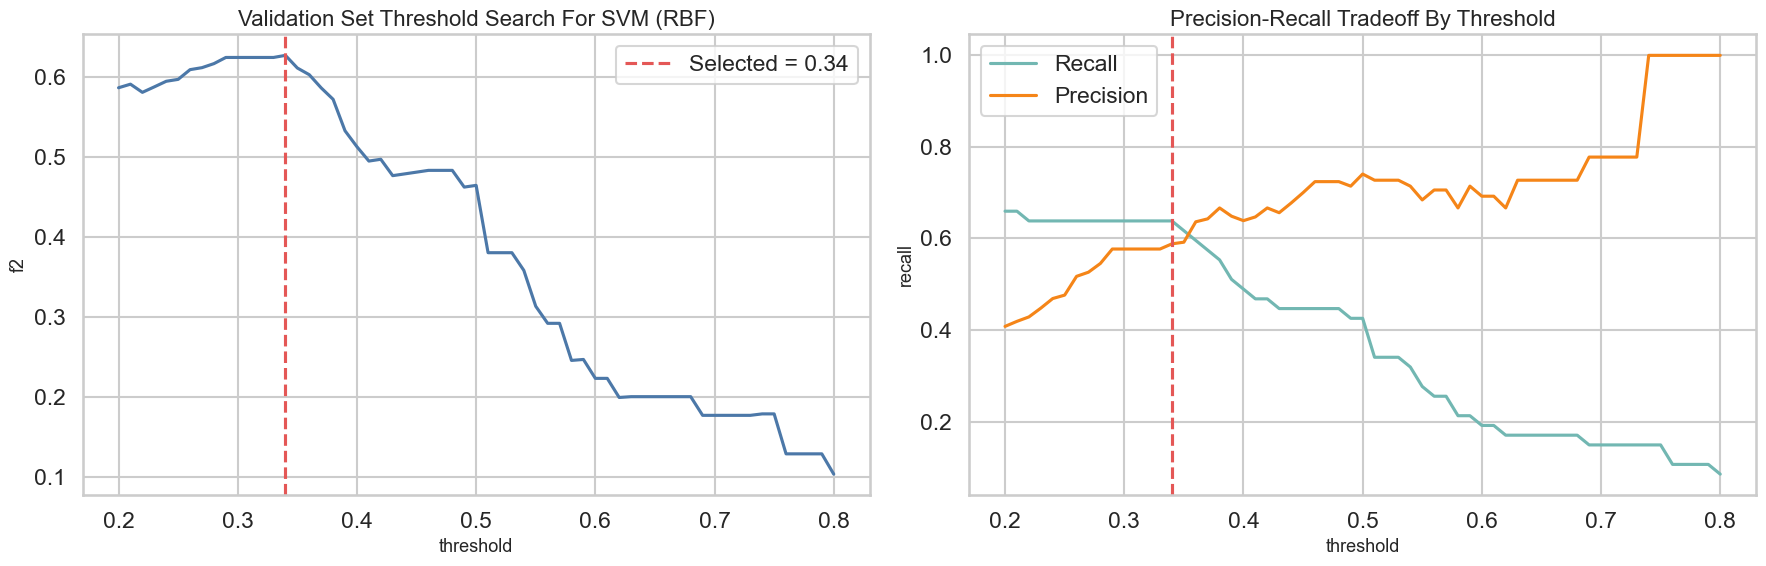

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(
    data=threshold_results.sort_values("threshold"),
    x="threshold",
    y="f2",
    ax=axes[0],
    color="#4C78A8",
)
axes[0].axvline(selected_threshold, color="#E45756", linestyle="--", label=f"Selected = {selected_threshold:.2f}")
axes[0].set_title(f"Validation Set Threshold Search For {recommended_blackbox_name}")
axes[0].legend()

sns.lineplot(
    data=threshold_results.sort_values("threshold"),
    x="threshold",
    y="recall",
    ax=axes[1],
    color="#72B7B2",
    label="Recall",
)
sns.lineplot(
    data=threshold_results.sort_values("threshold"),
    x="threshold",
    y="precision",
    ax=axes[1],
    color="#F58518",
    label="Precision",
)
axes[1].axvline(selected_threshold, color="#E45756", linestyle="--")
axes[1].set_title("Precision-Recall Tradeoff By Threshold")

plt.tight_layout()
plt.show()


## Final Evaluation Plots


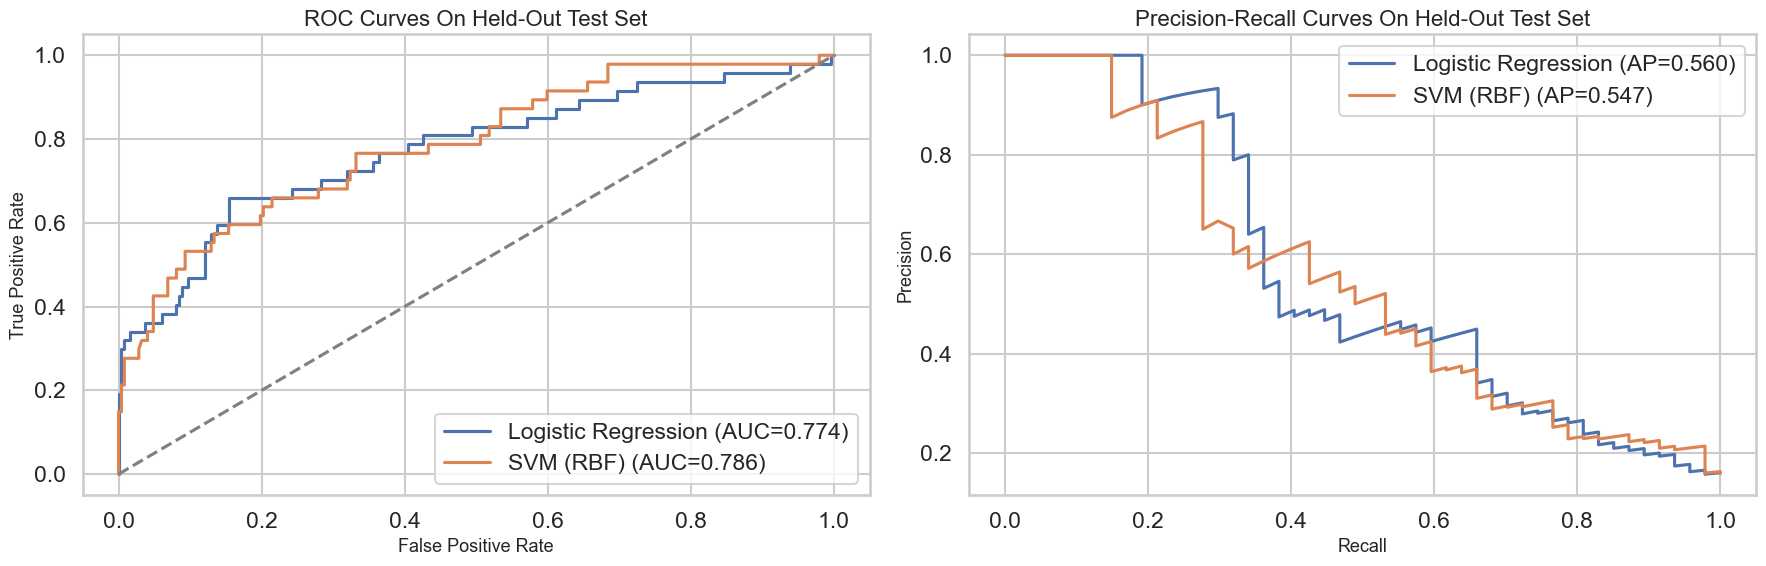

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for name in finalists:
    estimator = tuned_searches[name].best_estimator_
    proba = estimator.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, proba)
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, proba)

    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
    axes[1].plot(recall_curve, precision_curve, label=f"{name} (AP={average_precision_score(y_test, proba):.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("ROC Curves On Held-Out Test Set")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].set_title("Precision-Recall Curves On Held-Out Test Set")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()


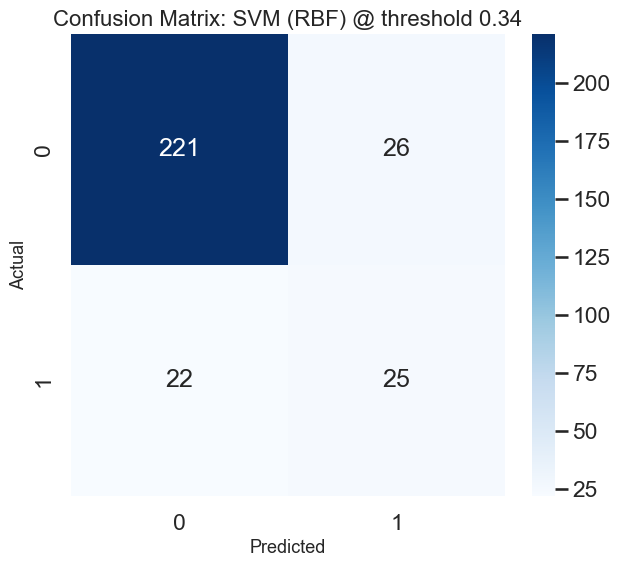

              precision    recall  f1-score   support

No Attrition       0.91      0.89      0.90       247
   Attrition       0.49      0.53      0.51        47

    accuracy                           0.84       294
   macro avg       0.70      0.71      0.71       294
weighted avg       0.84      0.84      0.84       294



In [34]:
final_blackbox_preds = (test_proba_blackbox >= selected_threshold).astype(int)
cm = confusion_matrix(y_test, final_blackbox_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {recommended_blackbox_name} @ threshold {selected_threshold:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, final_blackbox_preds, target_names=["No Attrition", "Attrition"]))


## Recommendation

The next cell prints a compact conclusion that you can reuse in your capstone write-up.


In [35]:
overall_model_name = best_overall_final["model"]
blackbox_model_name = best_blackbox_final["model"]

# Compute test metrics on-the-fly (they were printed earlier but not stored)
overall_test_proba_local = best_overall_estimator.predict_proba(X_test)[:, 1]
overall_test_pred_local = (overall_test_proba_local >= 0.5).astype(int)

blackbox_test_proba_local = best_blackbox_estimator.predict_proba(X_test)[:, 1]
blackbox_test_pred_local = (blackbox_test_proba_local >= 0.5).astype(int)

# Extract threshold-adjusted metrics
threshold_summary = threshold_test_results.loc[
    threshold_test_results["threshold"] == selected_threshold
].iloc[0]

print("Overall benchmark winner")
print(
    f"- {overall_model_name}: PR-AUC={average_precision_score(y_test, overall_test_proba_local):.3f}, "
    f"ROC-AUC={roc_auc_score(y_test, overall_test_proba_local):.3f}, "
    f"Recall={recall_score(y_test, overall_test_pred_local):.3f}, "
    f"Precision={precision_score(y_test, overall_test_pred_local, zero_division=0):.3f}, "
    f"F1={f1_score(y_test, overall_test_pred_local):.3f}"
)
print()
print("Recommended blackbox model")
print(
    f"- {blackbox_model_name}: PR-AUC={average_precision_score(y_test, blackbox_test_proba_local):.3f}, "
    f"ROC-AUC={roc_auc_score(y_test, blackbox_test_proba_local):.3f}, "
    f"Recall@0.50={recall_score(y_test, blackbox_test_pred_local):.3f}, "
    f"Precision@0.50={precision_score(y_test, blackbox_test_pred_local, zero_division=0):.3f}, "
    f"F1@0.50={f1_score(y_test, blackbox_test_pred_local):.3f}"
)
print(
    f"- Threshold-adjusted blackbox setting ({selected_threshold:.2f}) gives "
    f"Recall={threshold_summary['recall']:.3f}, "
    f"Precision={threshold_summary['precision']:.3f}, "
    f"F1={threshold_summary['f1']:.3f}, "
    f"Balanced Accuracy={threshold_summary['balanced_accuracy']:.3f}"
)
print()
print("Recommendation")
print(
    f"- Keep {overall_model_name} as the performance benchmark."
)
print(
    f"- Use {blackbox_model_name} as the blackbox handoff model for the next XAI phase."
)

Overall benchmark winner
- SVM (RBF): PR-AUC=0.547, ROC-AUC=0.786, Recall=0.319, Precision=0.652, F1=0.429

Recommended blackbox model
- SVM (RBF): PR-AUC=0.547, ROC-AUC=0.786, Recall@0.50=0.319, Precision@0.50=0.652, F1@0.50=0.429
- Threshold-adjusted blackbox setting (0.34) gives Recall=0.532, Precision=0.490, F1=0.510, Balanced Accuracy=0.713

Recommendation
- Keep SVM (RBF) as the performance benchmark.
- Use SVM (RBF) as the blackbox handoff model for the next XAI phase.
